# Day 8: Multi-Class Artificial Neural Network (ANN) Classifier

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## 1. Load Data

In [15]:
# Load the Mobile Price Classification training dataset from GitHub
train_url = "https://raw.githubusercontent.com/Vvijayaragupathy-uno/machinelearning/main/day-8/train.csv"
data = pd.read_csv(train_url)

print(data.head())

   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   three_g  touch_screen  wifi  price_

## 2. Understanding the Data (Exploratory Data Analysis)

In [16]:
# Check how many rows and columns
print("Data Shape:")
print(data.shape)

# Check data types and see if there are missing values
print("\nData Info:")
print(data.info())

# Look at statistical summary (mean, min, max)
print("\nStatistical Summary:")
print(data.describe())

# Double check for any hidden missing values
print("\nMissing Values:")
print(data.isnull().sum())

Data Shape:
(2000, 21)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        20

## 3. Visualizing Key Features (EDA)

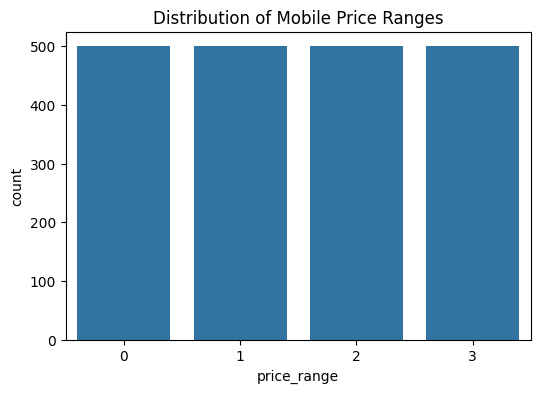

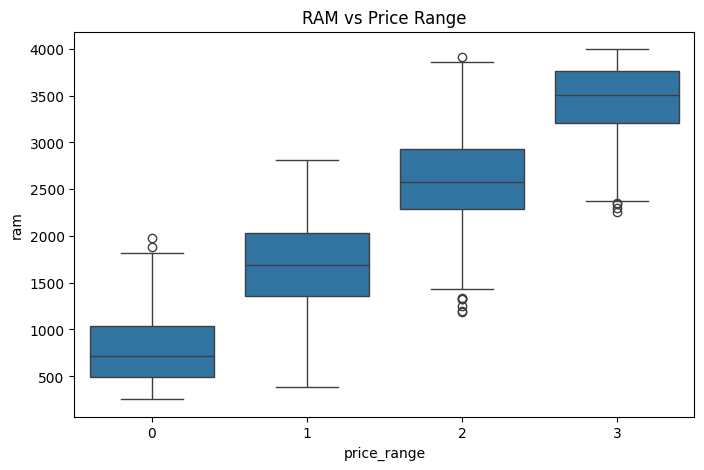

In [17]:
# Our goal is to predict the 'price_range'. Let's see how many phones are in each price range (0, 1, 2, 3)
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='price_range')
plt.title("Distribution of Mobile Price Ranges")
plt.show()

# Intuitively, RAM is a huge factor in mobile pricing. Let's visualize how RAM affects the price range.
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='price_range', y='ram')
plt.title("RAM vs Price Range")
plt.show()

## 4. Data Preprocessing & Splitting (Feature Engineering)

In [18]:
# 1. Separate features (X) and target (y)
X = data.drop(columns=['price_range'])
y = data['price_range']

# 2. Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features using StandardScaler
# Neural Networks perform much better when all numbers are scaled to a similar small range (like -1 to 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (1600, 20)
Testing data shape: (400, 20)


## 5. Build the Artificial Neural Network (ANN)



In [20]:
# We will build a simple Sequential Neural Network with Keras
model = keras.Sequential([
    # Input Layer (Hidden Layer 1) - 64 neurons, ReLU activation. 
    # input_shape must match the number of features we have (20 columns)
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    
    # Hidden Layer 2 - 32 neurons
    layers.Dense(32, activation='relu'),
    
    # Output Layer - 4 neurons because we have 4 price ranges (0, 1, 2, 3)
    # We use 'softmax' activation instead of 'sigmoid' because this is Multi-Class!
    layers.Dense(4, activation='softmax')
])

# Compile the model
# Since our target labels are integers (0, 1, 2, 3), we use sparse_categorical_crossentropy
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Show a summary of the network structure
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,556 (13.89 KB)

 Trainable params: 3,556 (13.89 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

In [21]:
# Train the model for 50 epochs (iterations over the dataset)
# We use a validation_split of 0.2 to check how the model performs on unseen data during training
history = model.fit(
    X_train_scaled, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2961 - loss: 1.3903 - val_accuracy: 0.3875 - val_loss: 1.2938
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4945 - loss: 1.1742 - val_accuracy: 0.5437 - val_loss: 1.1072
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6492 - loss: 0.9414 - val_accuracy: 0.6031 - val_loss: 0.8932
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7523 - loss: 0.7245 - val_accuracy: 0.7250 - val_loss: 0.7143
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8336 - loss: 0.5689 - val_accuracy: 0.7875 - val_loss: 0.5875
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8742 - loss: 0.4604 - val_accuracy: 0.8313 - val_loss: 0.4970
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9102 - loss: 0.3754 - val_accuracy: 0.8531 - val_loss: 0.4295
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9242 - loss: 0.3161 - val_accuracy: 0.8750 - val_loss:

## 7. Evaluate the Model


Final Test Accuracy: 92.25%

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       105
           1       0.88      0.92      0.90        91
           2       0.90      0.86      0.88        92
           3       0.93      0.96      0.94       112

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400



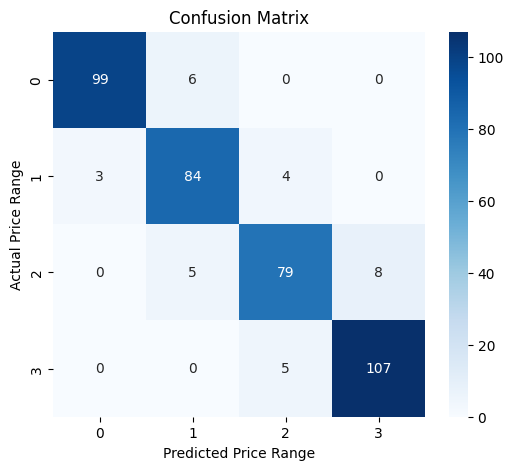

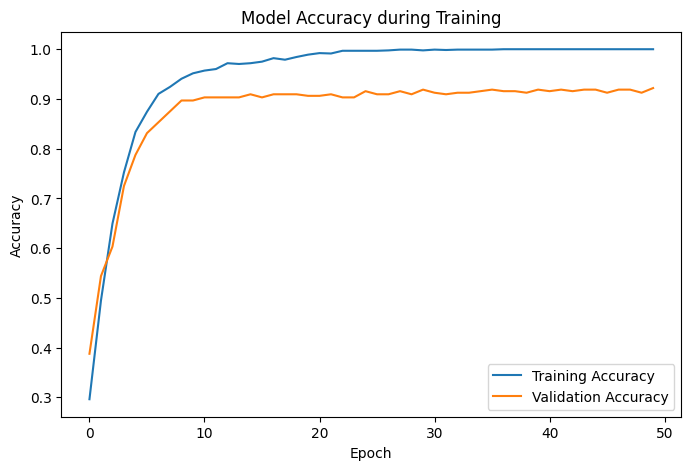

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Test the model on our completely unseen testing set
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%\n")

# 2. Get the actual predictions (probabilities) on the test set
y_pred_probs = model.predict(X_test_scaled)
# Convert probabilities to final class integers (0, 1, 2, or 3)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Print the Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 4. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Price Range')
plt.ylabel('Actual Price Range')
plt.show()

# 5. Plot the training vs validation accuracy over time
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy during Training')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## Activation Functions Explained:
*   **ReLU (Rectified Linear Unit)**: Used in the hidden layers. It outputs the input directly if it is positive, otherwise, it outputs zero. It helps the network learn complex patterns quickly.
*   **Sigmoid**: Squeezes numbers between 0 and 1. We would use this if we were predicting only TWO classes (Binary Classification, e.g., Is it a Dog or Cat?).
*   **Softmax**: Since we are predicting FOUR classes (Price ranges 0, 1, 2, 3), we use `softmax` for the final layer. It gives us a percentage probability for each of the 4 classes (e.g. 80% chance it is price range 3) and ensures all 4 probabilities add up to 100%.

##  Predictions



In [24]:
# 1. Load the blind test data from GitHub
test_url = "https://raw.githubusercontent.com/Vvijayaragupathy-uno/machinelearning/main/day-8/test.csv"
blind_test_data = pd.read_csv(test_url)

# Notice it has an 'id' column instead of a 'price_range' column!
print(blind_test_data.head(3))

   id  battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
0   1           1043     1          1.8         1  14       0           5   
1   2            841     1          0.5         1   4       1          61   
2   3           1807     1          2.8         0   1       0          27   

   m_dep  mobile_wt  ...  pc  px_height  px_width   ram  sc_h  sc_w  \
0    0.1        193  ...  16        226      1412  3476    12     7   
1    0.8        191  ...  12        746       857  3895     6     0   
2    0.9        186  ...   4       1270      1366  2396    17    10   

   talk_time  three_g  touch_screen  wifi  
0          2        0             1     0  
1          7        1             0     0  
2         10        0             1     1  

[3 rows x 21 columns]


In [25]:
# 2. We must drop the 'id' column because our Neural Network was trained on 20 features, not 21.
# (IDs are useless for math anyway!)
X_blind_test = blind_test_data.drop(columns=['id'])

# 3. We MUST scale this new data using the EXACT SAME scaler we fitted earlier on our training data.
X_blind_scaled = scaler.transform(X_blind_test)

# 4. Have the Neural Network make predictions!
# It will output 4 probabilities for each phone (because of our Softmax layer).
predictions_probabilities = model.predict(X_blind_scaled)

# Let's look at the raw probabilities for the very first phone
print("Probabilities for Phone #1:", predictions_probabilities[0])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Probabilities for Phone #1: [3.6812288e-21 2.0902847e-13 7.9331743e-03 9.9206686e-01]


In [30]:
# 5. Convert probabilities to a single final answer
# np.argmax picks the index of the highest probability (0, 1, 2, or 3)
final_predictions = np.argmax(predictions_probabilities, axis=1)

# Attach our AI's predictions back to the original test data so we can see the results
blind_test_data['Predicted_Price_Range'] = final_predictions

# Behold! Our AI has predicted the prices for all the unseen phones!
print("\nFinal Output with Predictions:")
display(blind_test_data[['id', 'Predicted_Price_Range']].head(10))


Final Output with Predictions:


,id,Predicted_Price_Range
0,1,3
1,2,3
2,3,2
3,4,3
4,5,1
5,6,3
6,7,3
7,8,1
8,9,3
9,10,0
